# Explaining Spatial Effects in Black-Box Models

**The Problem:** In many spatial datasets, the relationship between features and a target isn't constant. For example, the effect of `X1` on `y` might be strong in one area but weak in another. This is called **spatial heterogeneity**.

Traditional models like Geographically Weighted Regression (GWR) can capture this, but what about more powerful, non-linear models like XGBoost or Neural Networks? When they learn these complex relationships, they become "black boxes." In the field of geospatial artificial intelligence, there has been an emergence of location encoders which work to transform explicit location, ususally coordinates, into rich high-dimensional vectors called location embeddings. Location embeddings are crafted for downstream machine learning tasks to better learn complex spatial relationships. 

Ziqi Li created GeoShapely (https://github.com/Ziqi-Li/geoshapley) to better understand how spatial effects can be extracted from such algorithms. In this notebook, we will run evaluation experiments on models which leverage these location embeddings, combining the framework of GeoShapely and TorchSpatial (https://github.com/seai-lab/TorchSpatial). 

**Our Goal:** Can we train a black-box model and then *explain* it to recover the underlying spatially varying coefficients (SVCs) in black-box models which use location encoders?

## The Strategy

1.  **Engineer Location Features:** We convert `(x, y)` coordinates into rich, high-dimensional features called **location embeddings**.
2.  **Train a Model:** We train a standard ML model (like an MLP or XGBoost) using *both* the original features (`X1`, `X2`) and our new location embeddings.
3.  **Explain the Model:** We use an explanation framework, **GeoShapley**, to analyze the trained model. GeoShapley can separate the model's output into:
    * The *non-spatial* (global) effect of `X1`.
    * The *spatial* (local) effect of the location itself.
    * The *interaction* between `X1` and the location. This interaction *is* the spatially varying coefficient (SVC) we're looking for!

In [1]:
# --- Step 1: Imports --- 
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import torch

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from flaml import AutoML

# Explanation
from geoshapley import GeoShapleyExplainer

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Helper code from our project
# (We need to add the TorchSpatial directory to the path)
HERE = "." # Assuming we run from the root
TS_DIR = os.path.join(HERE, "TorchSpatial") 
if TS_DIR not in sys.path:
    sys.path.insert(0, TS_DIR)

# This will fail if 'TorchSpatial' isn't in the same directory
# If so, please update the path above.
try:
    from SpatialRelationEncoder import *
    from module import *
    from data_utils import *
    from utils import *
except ImportError as e:
    print(f"Error: Could not import from TorchSpatial. {e}")
    print(f"Please ensure 'TorchSpatial' directory is at: {TS_DIR}")

# Set a consistent grid size
SIZE = 25

# Set a consistent random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## --- Step 2: Load Simulated Data ---

We use a simulated dataset (`mgwr_sim.csv`) where we know the *exact* ground truth. This dataset is used from Ziqi Li's experiments. For more details, please see their GitHub repository and paper https://doi.org/10.48550/arXiv.2312.03675.
* `x_coord`, `y_coord`: Location.
* `X1`, `X2`: Two non-spatial features.
* `y`: The target variable.
* `b0`, `b1`, `b2`: The **true** spatially varying coefficients. `y` was generated using them.

In [2]:
print("Loading data...")
try:
    data_dir = "./data/mgwr_sim.csv"
    mgwr_sim = pd.read_csv(data_dir)
    print(f"Data loaded successfully from {data_dir}.")
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure 'mgwr_sim.csv' is in a './data' directory.")

original_coords = mgwr_sim[["x_coord", "y_coord"]].copy()
X_features = mgwr_sim[["X1", "X2"]].copy()
y = mgwr_sim.y.values
true_coeffs_df = mgwr_sim[["b0", "b1", "b2"]].copy()

true_intercept_surface = true_coeffs_df["b0"].values.flatten()
true_svc_x1_surface = true_coeffs_df["b1"].values.flatten()
true_svc_x2_surface = true_coeffs_df["b2"].values.flatten()

mgwr_sim.head()

Loading data...
Data loaded successfully from ./data/mgwr_sim.csv.


,Unnamed: 0,X1,X2,x_coord,y_coord,y,b0,b1,b2
0,0,0.136931,-1.896889,-12.0,-12.0,1.225547,3.0,1.000000,1.0
1,1,0.774086,1.559803,-11.0,-12.0,4.932787,3.0,1.083333,1.0
2,2,1.375514,-1.919209,-10.0,-12.0,2.603497,3.0,1.166667,1.0
3,3,0.647878,0.269916,-9.0,-12.0,3.461838,3.0,1.250000,1.0
4,4,-1.819095,0.082955,-8.0,-12.0,0.862135,3.0,1.333333,1.0


## --- Step 3: Define Helper Functions ---

Here are the key functions from our `help_utils.py` file, modified for this notebook:
1.  `get_loc_embeddings`: Now takes a `spa_embed_dim` argument so we can make it small and fast.
2.  `plot_s`: Modified to *only* display the plot (using `plt.show()`) and never save it to a file.
3.  `calculate_spatial_metrics`: A simplified version to quickly compare true vs. estimated surfaces (removed Moran's I for simplicity).

In [3]:
def get_loc_embeddings(coords, encoder_type, spa_embed_dim=12, device="cpu"):
    """
    Compute location embeddings, allowing for a variable embedding dimension.
    """
    params = {
        "spa_enc_type": encoder_type,
        "spa_embed_dim": spa_embed_dim,  # Use the provided dimension
        "extent": (0, 200, 0, 200), 
        "freq": 16, 
        "max_radius": 1, 
        "min_radius": 0.0001, 
        "spa_f_act": "leakyrelu", 
        "freq_init": "geometric", 
        "num_hidden_layer": 1, 
        "dropout": 0.5, 
        "hidden_dim": 512, 
        "use_layn": True, 
        "skip_connection": True, 
        "spa_enc_use_postmat": True, 
        "device": device,
    }

    loc_enc = get_spa_encoder(
        train_locs=[], 
        params=params,
        spa_enc_type=params["spa_enc_type"],
        spa_embed_dim=params["spa_embed_dim"],
        extent=params["extent"],
        coord_dim=2, 
        frequency_num=params["freq"],
        max_radius=params["max_radius"],
        min_radius=params["min_radius"],
        f_act=params["spa_f_act"],
        freq_init=params["freq_init"],
        use_postmat=params["spa_enc_use_postmat"],
        device=params["device"],
    ).to(params["device"])

    coords = np.array(coords)
    if coords.ndim == 2:
        coords = np.expand_dims(coords, axis=1)

    loc_embeds = torch.squeeze(loc_enc(coords))
    return loc_embeds




In [4]:
def plot_s(bs, size, vmin=None, vmax=None, title="", filename=None, experiment_dir=None):
    """
    Plots spatial coefficient surfaces and displays them inline.
    (This version is modified to NOT save files)
    """
    if not isinstance(bs, list):
        if isinstance(bs, np.ndarray) and bs.ndim == 2 and bs.shape[1] == size * size:
            bs = [bs[i, :] for i in range(bs.shape[0])]
        elif isinstance(bs, np.ndarray) and bs.ndim == 1 and bs.shape[0] == size * size:
            bs = [bs]
        else:
            print(f"Error: Invalid input for plot_s.")
            return

    k = len(bs)
    fig, axs = plt.subplots(1, k, figsize=(6 * k, 4), dpi=100) # Lower DPI for notebook
    if k == 1:
        axs = [axs]

    vmin_list = vmin if isinstance(vmin, list) else [vmin] * k
    vmax_list = vmax if isinstance(vmax, list) else [vmax] * k
    if len(vmin_list) != k or len(vmax_list) != k:
        vmin_list = [vmin_list[0]] * k
        vmax_list = [vmax_list[0]] * k

    plots_successful = 0
    for i in range(k):
        current_vmin = vmin_list[i]
        current_vmax = vmax_list[i]
        if (
            bs[i] is not None
            and hasattr(bs[i], "shape")
            and bs[i].shape == (size * size,)
        ):
            try:
                im = axs[i].imshow(
                    bs[i].reshape(size, size),
                    cmap="viridis",
                    vmin=current_vmin,
                    vmax=current_vmax,
                )
                fig.colorbar(im, ax=axs[i])
                axs[i].set_xticks([])
                axs[i].set_yticks([])
                if isinstance(title, list) and i < len(title):
                    axs[i].set_title(title[i], fontsize=16)
                plots_successful += 1
            except Exception as img_err:
                print(f"Error during imshow/colorbar for plot {i}: {img_err}")
        else:
            print(f"Warning: Skipping plot for component {i}.")

    if isinstance(title, str) and title:
        fig.suptitle(title, fontsize=18, y=1.02)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    
    # --- MODIFICATION --- 
    # Instead of saving, just show the plot inline.
    # We also remove plt.close(fig) to ensure it displays.
    if plots_successful > 0:
        plt.show()
    else:
        plt.close(fig) # Close if nothing was plotted


In [5]:
def calculate_spatial_metrics(
    true_surface,
    estimated_surface,
    effect_name,
    encoder_name,
    model_name,
):
    """
    Calculates basic metrics comparing true and estimated spatial surfaces.
    (Simplified version: removed Moran's I)
    """
    if true_surface is None or estimated_surface is None or true_surface.shape != estimated_surface.shape:
        print(f"Warning: Skipping metrics for {effect_name} due to shape mismatch or missing data.")
        return None

    metrics = {
        "encoder": encoder_name,
        "model": model_name,
        "spatial_effect": effect_name,
    }
    try:
        mask = ~np.isnan(true_surface) & ~np.isnan(estimated_surface)
        if np.sum(mask) < 2:
            print(f"Warning: Not enough valid data points for metrics.")
            return None

        true_valid = true_surface[mask]
        est_valid = estimated_surface[mask]

        metrics["mse"] = mean_squared_error(true_valid, est_valid)
        metrics["rmse"] = np.sqrt(metrics["mse"])
        metrics["mae"] = mean_absolute_error(true_valid, est_valid)

        if np.std(true_valid) > 1e-6 and np.std(est_valid) > 1e-6:
            pearson_r, _ = pearsonr(true_valid, est_valid)
            metrics["pearson_r"] = pearson_r
            metrics["pearson_r_squared"] = pearson_r**2
        else:
            metrics["pearson_r"] = np.nan
            metrics["pearson_r_squared"] = np.nan

        metrics["r2_score"] = r2_score(true_valid, est_valid)
        metrics["mean_error_bias"] = np.mean(est_valid - true_valid)

    except Exception as e:
        print(f"Error calculating metrics for {effect_name}: {e}")
        return None
    
    return metrics

## --- Step 4: Plot the Ground Truth --- 

This is what we are trying to find. These surfaces show how the intercept (`b0`) and the effects of `X1` (`b1`) and `X2` (`b2`) *truly* vary across the 25x25 grid.

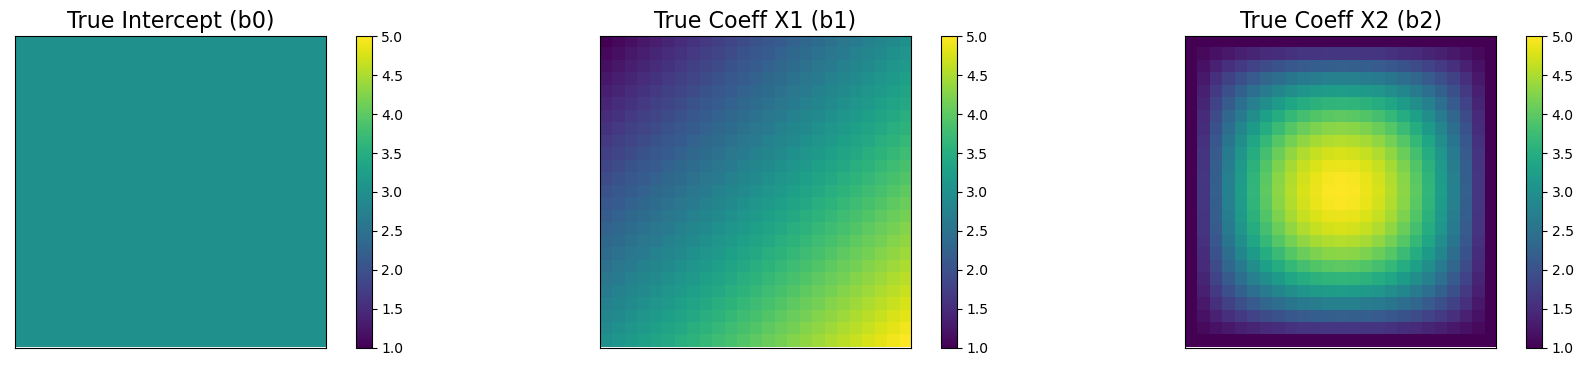

In [6]:
plot_s(
    [true_intercept_surface, true_svc_x1_surface, true_svc_x2_surface],
    size=SIZE,
    vmin=1,
    vmax=5,
    title=["True Intercept (b0)", "True Coeff X1 (b1)", "True Coeff X2 (b2)"],
)

## --- Step 5: Run a Simple Experiment --- 

We will run **one repetition** with **one encoder** and a **small embedding dimension** to make it fast.

In [7]:
# --- Experiment Setup ---
ENCODER_TO_RUN = "Space2Vec-grid" # A simple, fast encoder
SMALL_EMBED_DIM = 4              # User request: small dimension for speed

print(f"Generating {ENCODER_TO_RUN} location features with dim={SMALL_EMBED_DIM}...")
try:
    embeddings = get_loc_embeddings(
        original_coords.values, 
        encoder_type=ENCODER_TO_RUN, 
        spa_embed_dim=SMALL_EMBED_DIM, # Pass the small dim
        device="cpu"
    )

    if isinstance(embeddings, torch.Tensor):
        embeddings_np = embeddings.detach().cpu().numpy()
    else:
        embeddings_np = np.array(embeddings)
        
    if embeddings_np.ndim > 2:
        embeddings_np = np.squeeze(embeddings_np)
        
    if embeddings_np.ndim != 2 or embeddings_np.shape[0] != len(original_coords):
         raise ValueError(f"Embeddings have incorrect shape: {embeddings_np.shape}")

    emb_cols = [f"{ENCODER_TO_RUN}_emb_{i}" for i in range(SMALL_EMBED_DIM)]
    X_embeddings = pd.DataFrame(
        embeddings_np, columns=emb_cols, index=original_coords.index
    )
    print(f"Successfully created features of shape: {X_embeddings.shape}")

except Exception as e:
    print(f"Error generating embeddings: {e}. Notebook halted.")
    import traceback
    traceback.print_exc()
    # Stop execution if this fails
    raise e

Generating Space2Vec-grid location features with dim=4...
Successfully created features of shape: (625, 4)


In [8]:
# --- Prepare Data for ML and Explanation ---

# 1. Features for standard ML (X1, X2, Embeddings)
X_ml_features = pd.concat([X_features, X_embeddings], axis=1)
ml_feature_names = X_ml_features.columns.tolist()

# 2. Features for GeoShapley (ML Features + Coords)
X_for_geoshapley = pd.concat([X_ml_features, original_coords], axis=1)
geoshapley_feature_names = X_for_geoshapley.columns.tolist()

print(f"ML Features: {ml_feature_names}")

# --- Split Data ---
print(f"\nSplitting data (80/20 split) with random_state={RANDOM_STATE}...")
X_train_gs, X_test_gs, y_train, y_test = train_test_split(
    X_for_geoshapley,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE, 
)

# Get the ML-only parts of the split
X_train_ml = X_train_gs[ml_feature_names]
X_test_ml = X_test_gs[ml_feature_names]

# Data for explanation
background_data_gs = X_train_gs
explanation_data_gs = X_for_geoshapley # We explain on the *full* dataset

print(f"Train shape: {X_train_ml.shape}, Test shape: {X_test_ml.shape}")

ML Features: ['X1', 'X2', 'Space2Vec-grid_emb_0', 'Space2Vec-grid_emb_1', 'Space2Vec-grid_emb_2', 'Space2Vec-grid_emb_3']

Splitting data (80/20 split) with random_state=42...
Train shape: (500, 6), Test shape: (125, 6)


## --- Step 6: Model 1 - Multi-Layer Perceptron (MLP) --- 

First, we'll try a simple neural network. We'll use a standard `MLPRegressor` from `sklearn` (no complex hyperparameter search, just a default size).

In [9]:
# --- Train Simple MLP ---
print(f"Training simple MLP model...")
mlp_model = MLPRegressor(
    random_state=RANDOM_STATE, 
    hidden_layer_sizes=(50, 50), # A small network
    max_iter=500, 
    early_stopping=True,
    alpha=0.01
)

mlp_model.fit(X_train_ml, y_train)

mlp_train_score = mlp_model.score(X_train_ml, y_train)
mlp_test_score = mlp_model.score(X_test_ml, y_test)
print(f"  MLP Train R2: {mlp_train_score:.4f}")
print(f"  MLP Test R2:  {mlp_test_score:.4f}")

Training simple MLP model...
  MLP Train R2: 0.8808
  MLP Test R2:  0.8335



Explaining MLP model with GeoShapley...


  0%|          | 0/625 [00:00<?, ?it/s]

Explanation complete. Plotting GeoShapley summary...


/u/dkiv2/miniconda3/envs/e/lib/python3.9/site-packages/geoshapley/geoshapley.py:435: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(total, names, show=False, **kwargs)


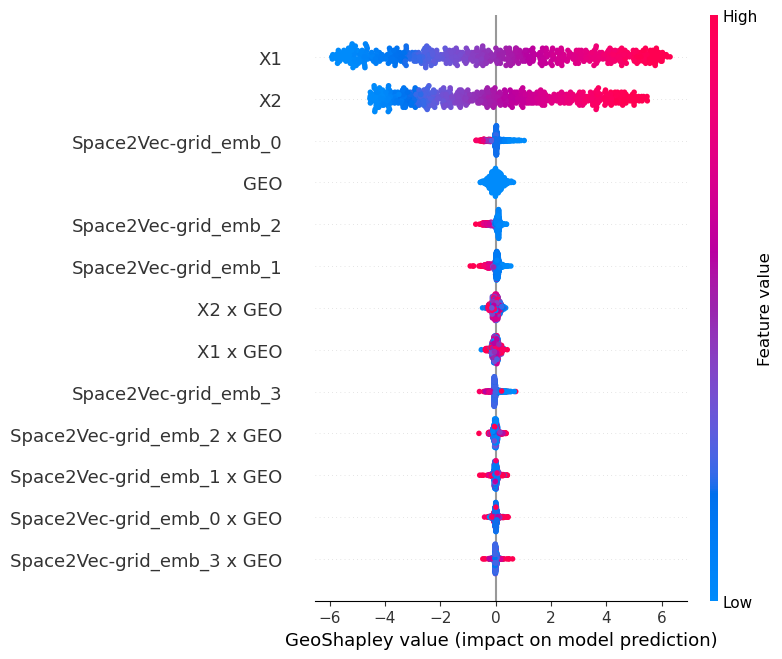

In [10]:
# --- Explain MLP with GeoShapley ---
print(f"\nExplaining MLP model with GeoShapley...")

# Define the prediction function GeoShapley needs
def mlp_predict_func(X_gs_df):
    if isinstance(X_gs_df, np.ndarray):
        X_gs_df = pd.DataFrame(X_gs_df, columns=geoshapley_feature_names)
    X_ml = X_gs_df[ml_feature_names]
    return mlp_model.predict(X_ml)

# Initialize and run the explainer
mlp_explainer = GeoShapleyExplainer(mlp_predict_func, background_data_gs.values)
mlp_rslt = mlp_explainer.explain(explanation_data_gs, n_jobs=-1)

print("Explanation complete. Plotting GeoShapley summary...")

# Use GeoShapley's built-in summary plot
# This shows which features (spatial, non-spatial, and interactions) matter most.
mlp_rslt.summary_plot(dpi=100)
plt.show()

Calculating estimated spatial surfaces for MLP...


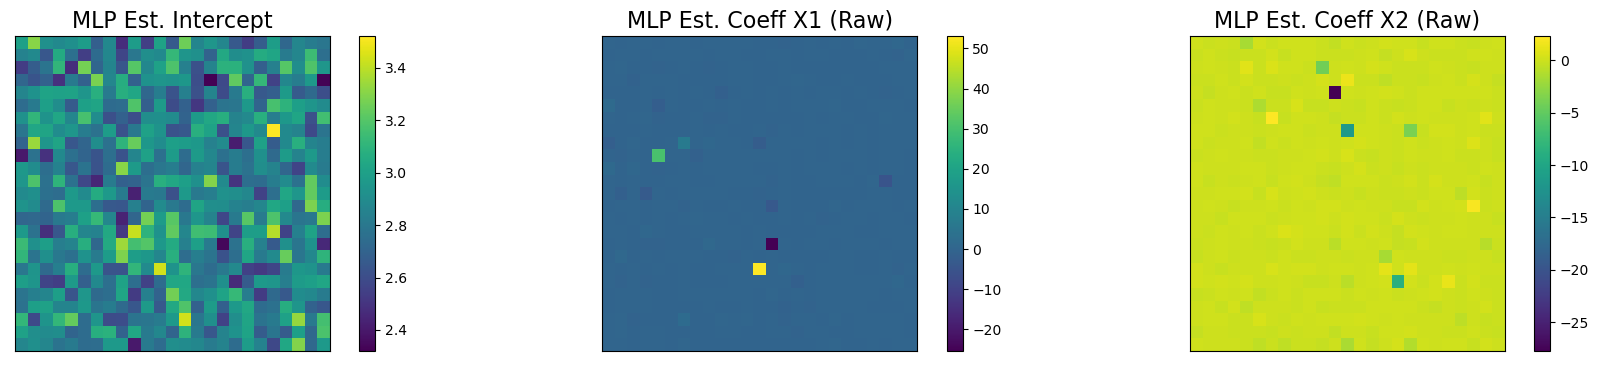

In [11]:
# --- Get MLP Estimated Surfaces ---
print("Calculating estimated spatial surfaces for MLP...")

# The spatial intercept is the base value + the pure 'geo' effect
est_intercept_mlp = mlp_rslt.base_value + mlp_rslt.geo

# The SVCs are the interactions between 'X1'/'X2' and 'geo'
original_feature_indices = [
    geoshapley_feature_names.index("X1"),
    geoshapley_feature_names.index("X2"),
]

mlp_svc_interactions_raw = mlp_rslt.get_svc(
    col=original_feature_indices, 
    coef_type="raw", # 'raw' = the pure interaction value
    include_primary=False
)

# --- Plot MLP Results ---
if mlp_svc_interactions_raw is not None:
    plot_s(
        [est_intercept_mlp, mlp_svc_interactions_raw[:, 0], mlp_svc_interactions_raw[:, 1]],
        size=SIZE,
        title=[
            "MLP Est. Intercept",
            "MLP Est. Coeff X1 (Raw)",
            "MLP Est. Coeff X2 (Raw)",
        ],
    )
else:
    print("Could not retrieve MLP SVC interactions.")

In [13]:
# --- Show MLP Metrics ---
mlp_metrics = []
mlp_metrics.append(calculate_spatial_metrics(
    true_intercept_surface, 
    est_intercept_mlp, 
    "Intercept", 
    ENCODER_TO_RUN, 
    "MLP"
))

if mlp_svc_interactions_raw is not None:
    mlp_metrics.append(calculate_spatial_metrics(
        true_svc_x1_surface, 
        mlp_svc_interactions_raw[:, 0], 
        "SVC_X1_Raw", 
        ENCODER_TO_RUN, 
        "MLP"
    ))
    mlp_metrics.append(calculate_spatial_metrics(
        true_svc_x2_surface, 
        mlp_svc_interactions_raw[:, 1], 
        "SVC_X2_Raw", 
        ENCODER_TO_RUN, 
        "MLP"
    ))

mlp_metrics_df = pd.DataFrame([m for m in mlp_metrics if m is not None])
display(mlp_metrics_df.set_index('spatial_effect'))

,encoder,model,mse,rmse,mae,pearson_r,pearson_r_squared,r2_score,mean_error_bias
spatial_effect,,,,,,,,,
Intercept,Space2Vec-grid,MLP,0.053642,0.231608,0.186643,NaN,NaN,0.000000,-0.133228
SVC_X1_Raw,Space2Vec-grid,MLP,16.448501,4.055675,3.174181,-0.008359,0.000070,-21.774847,-2.909614
SVC_X2_Raw,Space2Vec-grid,MLP,10.715831,3.273504,2.723420,-0.024956,0.000623,-6.010606,-2.723420


## --- Step 7: Model 2 - XGBoost (via FLAML) --- 

Now let's try a gradient boosting model. We'll use FLAML to quickly find a decent XGBoost model within a **very short time budget (15 seconds)**.

In [14]:
# --- Train XGBoost ---
print(f"Training XGBoost model with FLAML (15s budget)...")
automl_xgb = AutoML()
xgb_settings = {
    "time_budget": 15,  # Very short time for a quick demo
    "metric": 'r2',
    "task": 'regression',
    "estimator_list": ['xgboost'],
     "verbose": 0,
     "seed": RANDOM_STATE
}

try:
    automl_xgb.fit(X_train=X_train_ml, y_train=y_train, **xgb_settings)
    xgb_model = automl_xgb.model.estimator

    xgb_train_score = xgb_model.score(X_train_ml, y_train)
    xgb_test_score = xgb_model.score(X_test_ml, y_test)
    print(f"  Best XGBoost config: {automl_xgb.best_config}")
    print(f"  XGBoost Train R2: {xgb_train_score:.4f}")
    print(f"  XGBoost Test R2:  {xgb_test_score:.4f}")
except Exception as e:
    print(f"XGBoost training failed: {e}")
    xgb_model = None

Training XGBoost model with FLAML (15s budget)...
  Best XGBoost config: {'n_estimators': 65, 'max_leaves': 5, 'min_child_weight': 0.8064136973703431, 'learning_rate': 0.09694696947915007, 'subsample': 1.0, 'colsample_bylevel': 0.8646687000975802, 'colsample_bytree': 0.9733825394476897, 'reg_alpha': 0.0009765625, 'reg_lambda': 0.0063661446390706035}
  XGBoost Train R2: 0.9165
  XGBoost Test R2:  0.8276



Explaining XGBoost model with GeoShapley...


  0%|          | 0/625 [00:00<?, ?it/s]

Explanation complete. Plotting GeoShapley summary...


/u/dkiv2/miniconda3/envs/e/lib/python3.9/site-packages/geoshapley/geoshapley.py:435: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(total, names, show=False, **kwargs)


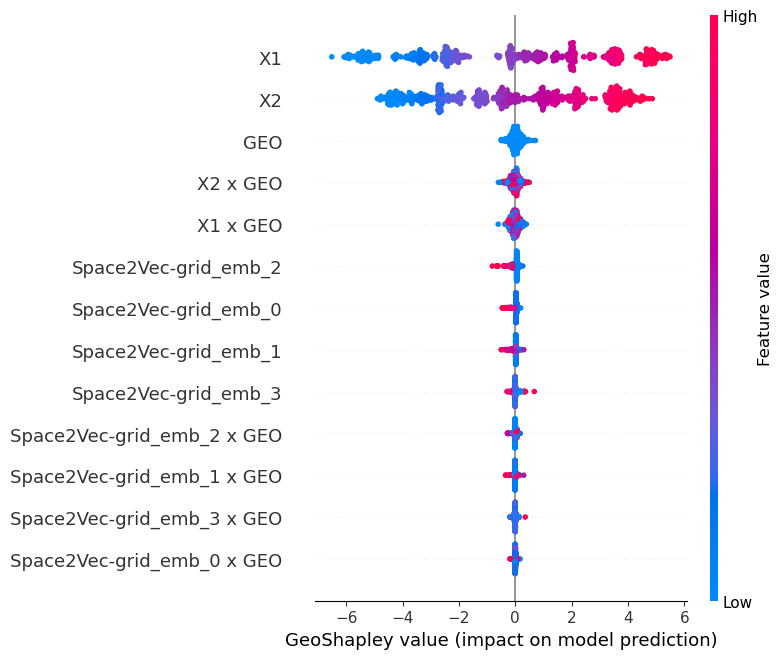

In [15]:
# --- Explain XGBoost with GeoShapley ---
if xgb_model is not None:
    print(f"\nExplaining XGBoost model with GeoShapley...")

    def xgb_predict_func(X_gs_df):
        if isinstance(X_gs_df, np.ndarray):
            X_gs_df = pd.DataFrame(X_gs_df, columns=geoshapley_feature_names)
        X_ml = X_gs_df[ml_feature_names]
        return xgb_model.predict(X_ml)

    xgb_explainer = GeoShapleyExplainer(xgb_predict_func, background_data_gs.values)
    xgb_rslt = xgb_explainer.explain(explanation_data_gs, n_jobs=-1)

    print("Explanation complete. Plotting GeoShapley summary...")
    xgb_rslt.summary_plot(dpi=100)
    plt.show()
else:
    print("Skipping XGBoost explanation as model training failed.")
    xgb_rslt = None

Calculating estimated spatial surfaces for XGBoost...


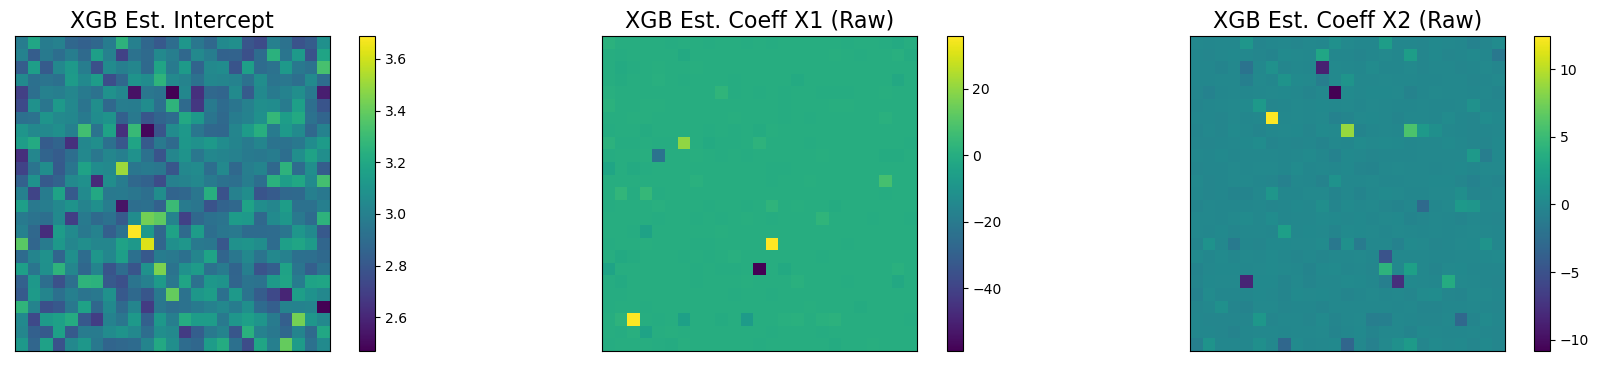

In [16]:
# --- Get XGBoost Estimated Surfaces ---
if xgb_rslt is not None:
    print("Calculating estimated spatial surfaces for XGBoost...")

    est_intercept_xgb = xgb_rslt.base_value + xgb_rslt.geo
    xgb_svc_interactions_raw = xgb_rslt.get_svc(
        col=original_feature_indices, 
        coef_type="raw", 
        include_primary=False
    )

    # --- Plot XGBoost Results ---
    if xgb_svc_interactions_raw is not None:
        plot_s(
            [est_intercept_xgb, xgb_svc_interactions_raw[:, 0], xgb_svc_interactions_raw[:, 1]],
            size=SIZE,
            title=[
                "XGB Est. Intercept",
                "XGB Est. Coeff X1 (Raw)",
                "XGB Est. Coeff X2 (Raw)",
            ],
        )
    else:
        print("Could not retrieve XGB SVC interactions.")
else:
    print("Skipping XGBoost results as explanation was not run.")
    xgb_svc_interactions_raw = None

In [17]:
# --- Show XGBoost Metrics ---
xgb_metrics = []
if xgb_rslt is not None:
    xgb_metrics.append(calculate_spatial_metrics(
        true_intercept_surface, 
        est_intercept_xgb, 
        "Intercept", 
        ENCODER_TO_RUN, 
        "XGBoost"
    ))

if xgb_svc_interactions_raw is not None:
    xgb_metrics.append(calculate_spatial_metrics(
        true_svc_x1_surface, 
        xgb_svc_interactions_raw[:, 0], 
        "SVC_X1_Raw", 
        ENCODER_TO_RUN, 
        "XGBoost"
    ))
    xgb_metrics.append(calculate_spatial_metrics(
        true_svc_x2_surface, 
        xgb_svc_interactions_raw[:, 1], 
        "SVC_X2_Raw", 
        ENCODER_TO_RUN, 
        "XGBoost"
    ))

if xgb_metrics:
    xgb_metrics_df = pd.DataFrame([m for m in xgb_metrics if m is not None])
    display(xgb_metrics_df.set_index('spatial_effect'))
else:
    print("No metrics to display for XGBoost.")

,encoder,model,mse,rmse,mae,pearson_r,pearson_r_squared,r2_score,mean_error_bias
spatial_effect,,,,,,,,,
Intercept,Space2Vec-grid,XGBoost,0.022790,0.150963,0.114872,NaN,NaN,0.000000,-0.013355
SVC_X1_Raw,Space2Vec-grid,XGBoost,21.178779,4.602041,3.269841,-0.003942,0.000016,-28.324463,-2.974834
SVC_X2_Raw,Space2Vec-grid,XGBoost,9.552797,3.090760,2.694088,0.039234,0.001539,-5.249716,-2.625172


## --- Step 8: Conclusion --- 

As we can see from the plots and metrics (especially the `pearson_r_squared` or `r2_score`), this method allows us to train complex, black-box ML models and successfully recover the underlying spatial processes.

The model doesn't just make a good prediction; thanks to the location embeddings and GeoShapley, we can *explain* it and find the spatially varying coefficients, turning the black box into an interpretable tool for spatial analysis. 